In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.utils import resample
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel(r'datos_tratados_6.xlsx', sheet_name = "Sheet1")

## División de datasets

In [3]:
dataF = data
dataF = dataF.drop(columns=['tinygsSatellite'])
dataF.index = range(dataF.shape[0])

data1 = data[data['tinygsSatellite'] == 'CSTP-1.1']
data1 = data1.drop(columns=['tinygsSatellite'])
data1.index = range(data1.shape[0])

data2 = data[data['tinygsSatellite'] == 'CSTP-1.2']
data2 = data2.drop(columns=['tinygsSatellite'])
data2.index = range(data2.shape[0])

data3 = data[data['tinygsSatellite'] == 'Polytech_Universe-3']
data3 = data3.drop(columns=['tinygsSatellite'])
data3.index = range(data3.shape[0])

## Tratamiento de variables categóricas

In [4]:
# Tratamiento de variables categóricas mediante One-Hot encoder: tinygsSatellite, psuFlags, psuFlag2, bat1Flag, chargerFlag
oheF = OneHotEncoder(sparse_output=False)
ohe1 = OneHotEncoder(sparse_output=False)
ohe2 = OneHotEncoder(sparse_output=False)
ohe3 = OneHotEncoder(sparse_output=False)

# Aplicar One-Hot Encoding
df_oheF = oheF.fit_transform(dataF[['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']])
df_ohe1 = ohe1.fit_transform(data1[['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']])
df_ohe2 = ohe2.fit_transform(data2[['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']])
df_ohe3 = ohe3.fit_transform(data3[['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']])

# Convertir a DataFrame y asignar nombres de columnas
df_oheF = pd.DataFrame(df_oheF, columns=oheF.get_feature_names_out(['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']))
df_ohe1 = pd.DataFrame(df_ohe1, columns=ohe1.get_feature_names_out(['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']))
df_ohe2 = pd.DataFrame(df_ohe2, columns=ohe2.get_feature_names_out(['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']))
df_ohe3 = pd.DataFrame(df_ohe3, columns=ohe3.get_feature_names_out(['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']))

# Concatenar con el DataFrame original
dataF = pd.concat([dataF, df_oheF], axis=1)
data1 = pd.concat([data1, df_ohe1], axis=1)
data2 = pd.concat([data2, df_ohe2], axis=1)
data3 = pd.concat([data3, df_ohe3], axis=1)

# Eliminamos las variables categóricas no tratadas
dataF = dataF.drop(columns=['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag'])
data1 = data1.drop(columns=['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag'])
data2 = data2.drop(columns=['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag'])
data3 = data3.drop(columns=['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag'])

In [5]:
print(dataF.shape)
print(data1.shape)
print(data2.shape)
print(data3.shape)

(8844, 53)
(2614, 49)
(3219, 36)
(3011, 41)


In [6]:
# Calculamos la desviación de las nuevas variables -> borrar bat1Flag_2
dataF.std()

satUptime              49900.067804
psuTemp                    9.802430
batCharge                  0.774392
tempBatMin                 2.094913
tempBatMax                 2.185143
iPsuCh1                    3.070362
iPsuCh2                    3.207007
iPsuCh3                    2.316184
iPsuCh5                    2.585028
iPsuCh6                    2.189323
iPsuCh7                    4.054861
bat1I                    163.752201
bat1Cap                  864.140553
bat2I                    163.042006
bat2Cap                  861.522949
tinygsSolarVoltage2        8.275557
tinygsSolarVoltage3        9.087277
tinygsVbus               729.099913
tinygsSolarCurrent1       77.172488
tinygsBatVoltage2        734.958985
tinygsSolarCurrent2       68.846693
tinygsIbus               325.089840
tinygsBatVoltage         716.476310
tinygsSolarCurrent3       85.460777
tinygsSolarVoltage1        8.425991
psuFlags_3843              0.499974
psuFlags_3845              0.414294
psuFlags_3846              0

In [7]:
# Calculamos la desviación de las nuevas variables -> borrar psuFlag2_4, bat1Flag_50, iPsuCh1, iPsuCh2, iPsuCh5, iPsuCh6, iPsuCh7
data2.std()

satUptime              43699.997031
psuTemp                    9.421666
batCharge                  0.218011
tempBatMin                 1.444500
tempBatMax                 1.484956
iPsuCh1                    0.000000
iPsuCh2                    0.000000
iPsuCh3                    0.078590
iPsuCh5                    0.000000
iPsuCh6                    0.000000
iPsuCh7                    0.000000
bat1I                     39.246425
bat1Cap                   29.467004
bat2I                     39.504098
bat2Cap                   29.868167
tinygsSolarVoltage2        8.752041
tinygsSolarVoltage3        9.616978
tinygsVbus                58.590007
tinygsSolarCurrent1       36.615979
tinygsBatVoltage2         59.178935
tinygsSolarCurrent2       36.349016
tinygsIbus                 3.815678
tinygsBatVoltage          58.737868
tinygsSolarCurrent3       35.687494
tinygsSolarVoltage1        8.670822
psuFlags_3843              0.489026
psuFlags_3845              0.489026
psuFlag2_4                 0

In [8]:
# Calculamos la desviación de las nuevas variables -> borrar bat1Flag_2
data3.std()

satUptime              51562.447243
psuTemp                    9.582481
batCharge                  1.041734
tempBatMin                 1.803950
tempBatMax                 1.729729
iPsuCh1                    0.902495
iPsuCh2                    1.541789
iPsuCh3                    0.871675
iPsuCh5                    0.743114
iPsuCh6                    0.464895
iPsuCh7                    1.962510
bat1I                    122.968739
bat1Cap                   57.521412
bat2I                    115.479829
bat2Cap                   54.560795
tinygsSolarVoltage2        8.255125
tinygsSolarVoltage3        8.586323
tinygsVbus                53.953312
tinygsSolarCurrent1       29.765087
tinygsBatVoltage2         51.734385
tinygsSolarCurrent2       29.902388
tinygsIbus               161.416917
tinygsBatVoltage          52.243198
tinygsSolarCurrent3      105.161069
tinygsSolarVoltage1        8.433335
psuFlags_3843              0.496436
psuFlags_3846              0.496436
psuFlag2_4                 0

In [9]:
# Se descartan los campos que no aportan información
data1 = data1.drop(columns=['bat1Flag_2'])
data2 = data2.drop(columns=['psuFlag2_4', 'bat1Flag_50', 'iPsuCh1', 'iPsuCh2', 'iPsuCh5', 'iPsuCh6', 'iPsuCh7'])
data3 = data3.drop(columns=['bat1Flag_2'])

## Normalización

In [7]:
# Se formatea el tiempo y se elimina para normalización
sat_time_originalF = dataF['satUptime']
sat_timeF = sat_time_originalF - min(sat_time_originalF)
dataF = dataF.drop(columns=['satUptime'])

sat_time_original1 = data1['satUptime']
sat_time1 = sat_time_original1 - min(sat_time_original1)
data1 = data1.drop(columns=['satUptime'])

sat_time_original2 = data2['satUptime']
sat_time2 = sat_time_original2 - min(sat_time_original2)
data2 = data2.drop(columns=['satUptime'])

sat_time_original3 = data3['satUptime']
sat_time3 = sat_time_original3 - min(sat_time_original3)
data3 = data3.drop(columns=['satUptime'])

In [8]:
# Normalizar datos
scalerF = MinMaxScaler()
scaler1 = MinMaxScaler()
scaler2 = MinMaxScaler()
scaler3 = MinMaxScaler()

data_scaledF = scalerF.fit_transform(dataF)
data_scaled1 = scaler1.fit_transform(data1)
data_scaled2 = scaler2.fit_transform(data2)
data_scaled3 = scaler3.fit_transform(data3)

data_scaledF = pd.DataFrame(data_scaledF, columns=dataF.columns)
data_scaled1 = pd.DataFrame(data_scaled1, columns=data1.columns)
data_scaled2 = pd.DataFrame(data_scaled2, columns=data2.columns)
data_scaled3 = pd.DataFrame(data_scaled3, columns=data3.columns)

## Clasificación de anomalías

### Método del codo

C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory lea

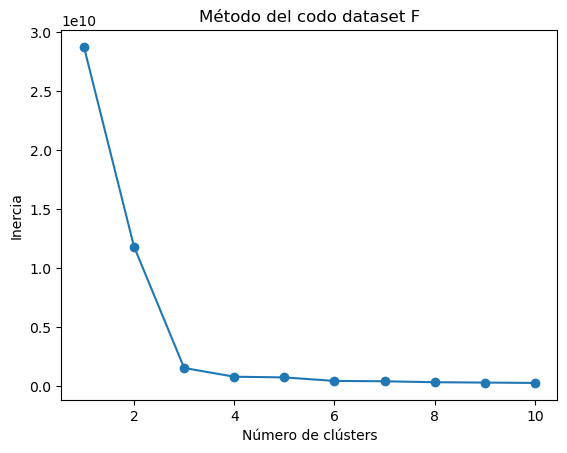

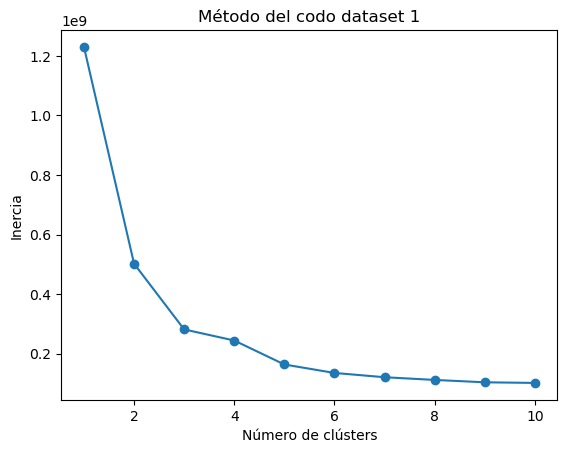

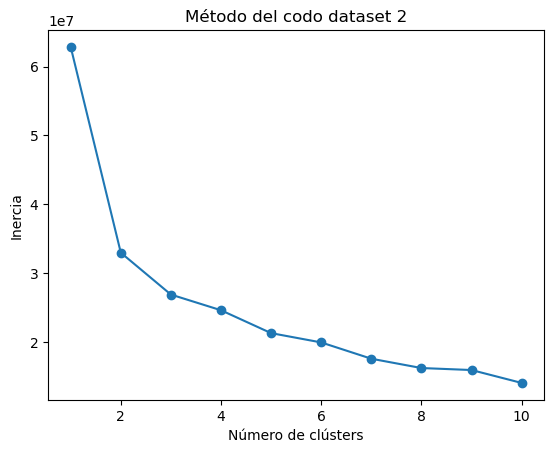

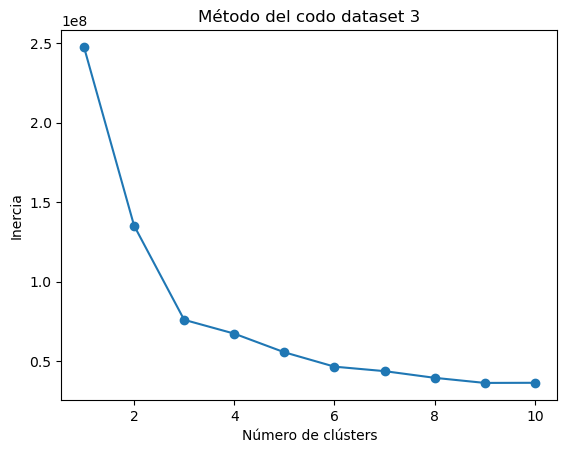

In [9]:
# Aplicamos el método del codo para determinar el número óptimo de clústers
inertiasF = []
inertias1 = []
inertias2 = []
inertias3 = []

for i in range(1,11):
    kmeansF = KMeans(n_clusters=i)
    kmeans1 = KMeans(n_clusters=i)
    kmeans2 = KMeans(n_clusters=i)
    kmeans3 = KMeans(n_clusters=i)

    kmeansF.fit(dataF)
    kmeans1.fit(data1)
    kmeans2.fit(data2)
    kmeans3.fit(data3)

    inertiasF.append(kmeansF.inertia_)
    inertias1.append(kmeans1.inertia_)
    inertias2.append(kmeans2.inertia_)
    inertias3.append(kmeans3.inertia_)

plt.plot(range(1,11), inertiasF, marker='o')
plt.title('Método del codo dataset F')
plt.xlabel('Número de clústers')
plt.ylabel('Inercia')
plt.show()

plt.plot(range(1,11), inertias1, marker='o')
plt.title('Método del codo dataset 1')
plt.xlabel('Número de clústers')
plt.ylabel('Inercia')
plt.show()

plt.plot(range(1,11), inertias2, marker='o')
plt.title('Método del codo dataset 2')
plt.xlabel('Número de clústers')
plt.ylabel('Inercia')
plt.show()

plt.plot(range(1,11), inertias3, marker='o')
plt.title('Método del codo dataset 3')
plt.xlabel('Número de clústers')
plt.ylabel('Inercia')
plt.show()

### K-means

In [10]:
# Aplicación de K-means para el K-óptimo según el método del codo DATASET 1
k = 3
kmeansF = KMeans(n_clusters=k)
kmeansF.fit(dataF)
distancesF = kmeansF.transform(dataF)
min_distancesF = np.min(distancesF, axis=1)
thresholdF = np.percentile(min_distancesF, 95)  # Top 5% as anomalies
anomaliesF = dataF[min_distancesF > thresholdF]

In [12]:
# Aplicamos PCA para ver una representación gráfica
pca_num_components = 2
pcaF = PCA(n_components=pca_num_components)
reduced_dataF = pcaF.fit_transform(dataF.iloc[:,0:52])
resultsF = pd.DataFrame(reduced_dataF,columns=['pca1','pca2'])

# Transformamos los centros
centersF=pcaF.transform(kmeansF.cluster_centers_)

C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


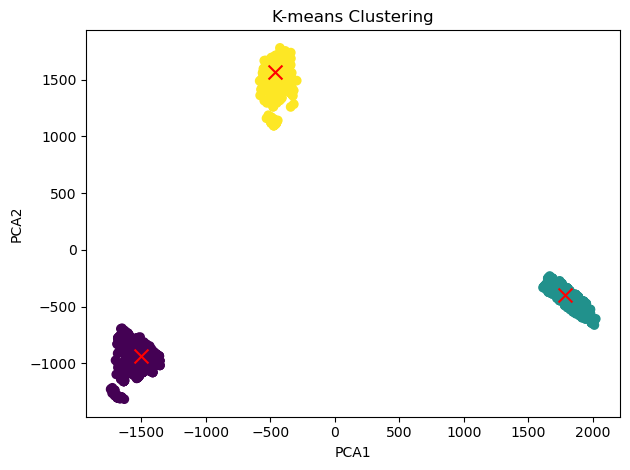

In [13]:
# Gráfico de resultados
plt.scatter(resultsF['pca1'],resultsF['pca2'],c=kmeansF.labels_)
plt.scatter(centersF[:,0],centersF[:,1],marker='x',s=100,c='red')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('K-means Clustering')
plt.tight_layout()

#### Dataset 1

In [14]:
# Aplicación de K-means para el K-óptimo según el método del codo DATASET 1
k = 4
kmeans1 = KMeans(n_clusters=k)
kmeans1.fit(data1)
distances1 = kmeans1.transform(data1)
min_distances1 = np.min(distances1, axis=1)
threshold1 = np.percentile(min_distances1, 95)  # Top 5% as anomalies
anomalies1 = data1[min_distances1 > threshold1]

C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


In [15]:
# Aplicamos PCA para ver una representación gráfica
pca_num_components = 2
pca1 = PCA(n_components=pca_num_components)
reduced_data1 = pca1.fit_transform(data1.iloc[:,0:49])
results1 = pd.DataFrame(reduced_data1,columns=['pca1','pca2'])

In [16]:
# Transformamos los centros
centers1=pca1.transform(kmeans1.cluster_centers_)

C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


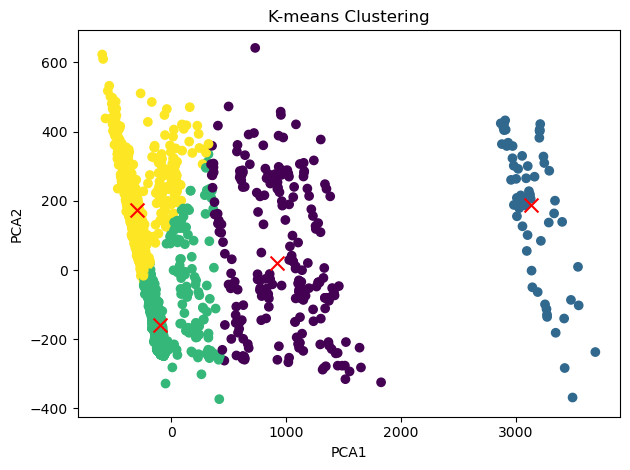

In [17]:
# Gráfico de resultados
plt.scatter(results1['pca1'],results1['pca2'],c=kmeans1.labels_)
plt.scatter(centers1[:,0],centers1[:,1],marker='x',s=100,c='red')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('K-means Clustering')
plt.tight_layout()

#### Dataset 2

In [18]:
# Aplicación de K-means para el K-óptimo según el método del codo DATASET 2
k = 2
kmeans2 = KMeans(n_clusters=k)
kmeans2.fit(data2)
distances2 = kmeans2.transform(data2)
min_distances2 = np.min(distances2, axis=1)
threshold2 = np.percentile(min_distances2, 95)  # Top 5% as anomalies
anomalies2 = data2[min_distances2 > threshold2]

C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


In [19]:
# Aplicamos PCA para ver una representación gráfica
pca_num_components = 2
pca2 = PCA(n_components=pca_num_components)
reduced_data2 = pca2.fit_transform(data2.iloc[:,0:49])
results2 = pd.DataFrame(reduced_data2,columns=['pca1','pca2'])

# Transformamos los centros
centers2=pca2.transform(kmeans2.cluster_centers_)

C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


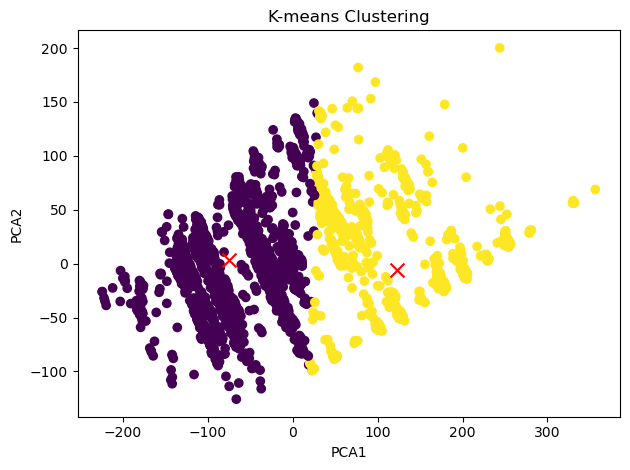

In [20]:
# Gráfico de resultados
plt.scatter(results2['pca1'],results2['pca2'],c=kmeans2.labels_)
plt.scatter(centers2[:,0],centers2[:,1],marker='x',s=100,c='red')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('K-means Clustering')
plt.tight_layout()

#### Dataset 3

In [21]:
# Aplicación de K-means para el K-óptimo según el método del codo DATASET 3
k = 3
kmeans3 = KMeans(n_clusters=k)
kmeans3.fit(data3)
distances3 = kmeans3.transform(data3)
min_distances3 = np.min(distances3, axis=1)
threshold3 = np.percentile(min_distances3, 95)  # Top 5% as anomalies
anomalies3 = data3[min_distances3 > threshold3]

C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


In [22]:
# Aplicamos PCA para ver una representación gráfica
pca_num_components = 2
pca3 = PCA(n_components=pca_num_components)
reduced_data3 = pca3.fit_transform(data3.iloc[:,0:49])
results3 = pd.DataFrame(reduced_data3,columns=['pca1','pca2'])

# Transformamos los centros
centers3=pca3.transform(kmeans3.cluster_centers_)

C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


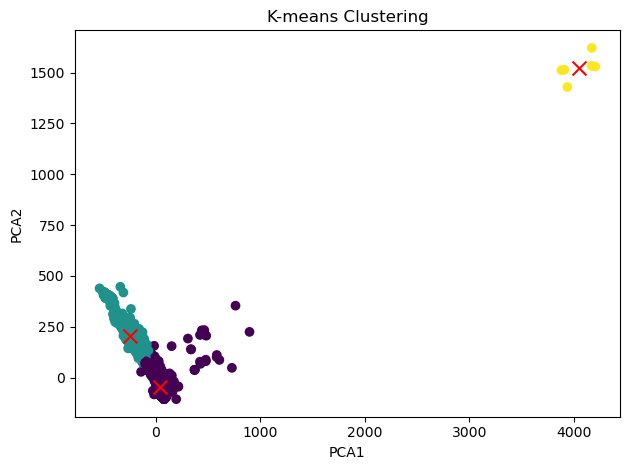

In [23]:
# Gráfico de resultados
plt.scatter(results3['pca1'],results3['pca2'],c=kmeans3.labels_)
plt.scatter(centers3[:,0],centers3[:,1],marker='x',s=100,c='red')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('K-means Clustering')
plt.tight_layout()

### Etiquetado de anomalías

In [25]:
#Etiquetamos las anomalías
data_scaledF['anomaly'] = [1 if min_distancesF[x] > thresholdF else 0 for x in range(data_scaledF.shape[0])]
data_scaled1['anomaly'] = [1 if min_distances1[x] > threshold1 else 0 for x in range(data_scaled1.shape[0])]
data_scaled2['anomaly'] = [1 if min_distances2[x] > threshold2 else 0 for x in range(data_scaled2.shape[0])]
data_scaled3['anomaly'] = [1 if min_distances3[x] > threshold3 else 0 for x in range(data_scaled3.shape[0])]

In [26]:
# Añadimos la variable temporal
data_scaledF['time'] = sat_timeF
data_scaled1['time'] = sat_time1
data_scaled2['time'] = sat_time2
data_scaled3['time'] = sat_time3

In [27]:
# Aplicamos PCA con la variable ANOMALY para ver una representación gráfica
pca_num_components = 2

pcaF = PCA(n_components=pca_num_components)
reduced_dataF = pcaF.fit_transform(dataF.iloc[:,0:55])
resultsF = pd.DataFrame(reduced_dataF,columns=['pca1','pca2'])

pca1 = PCA(n_components=pca_num_components)
reduced_data1 = pca1.fit_transform(data1.iloc[:,0:55])
results1 = pd.DataFrame(reduced_data1,columns=['pca1','pca2'])

pca2 = PCA(n_components=pca_num_components)
reduced_data2 = pca2.fit_transform(data2.iloc[:,0:55])
results2 = pd.DataFrame(reduced_data2,columns=['pca1','pca2'])

pca3 = PCA(n_components=pca_num_components)
reduced_data3 = pca3.fit_transform(data3.iloc[:,0:55])
results3 = pd.DataFrame(reduced_data3,columns=['pca1','pca2'])

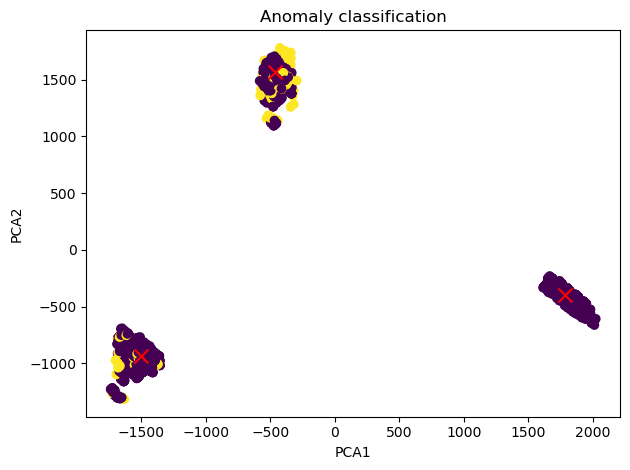

In [28]:
# Gráfico de datos y anomalías DATASETF
plt.scatter(resultsF['pca1'],resultsF['pca2'],c=data_scaledF['anomaly'])
plt.scatter(centersF[:,0],centersF[:,1],marker='x',s=100,c='red')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Anomaly classification')
plt.tight_layout()

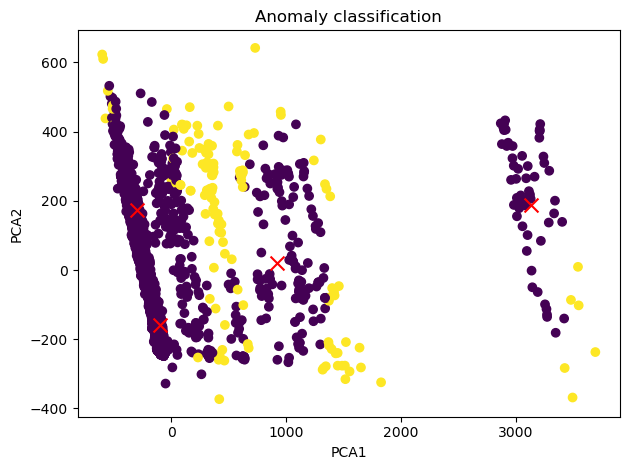

In [29]:
# Gráfico de datos y anomalías DATASET1
plt.scatter(results1['pca1'],results1['pca2'],c=data_scaled1['anomaly'])
plt.scatter(centers1[:,0],centers1[:,1],marker='x',s=100,c='red')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Anomaly classification')
plt.tight_layout()

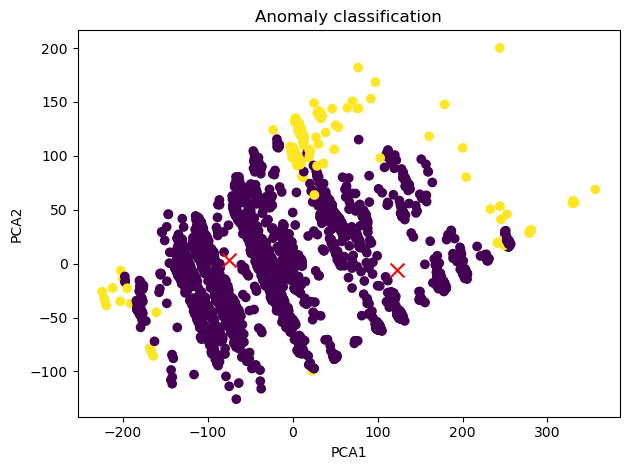

In [30]:
# Gráfico de datos y anomalías DATASET2
plt.scatter(results2['pca1'],results2['pca2'],c=data_scaled2['anomaly'])
plt.scatter(centers2[:,0],centers2[:,1],marker='x',s=100,c='red')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Anomaly classification')
plt.tight_layout()

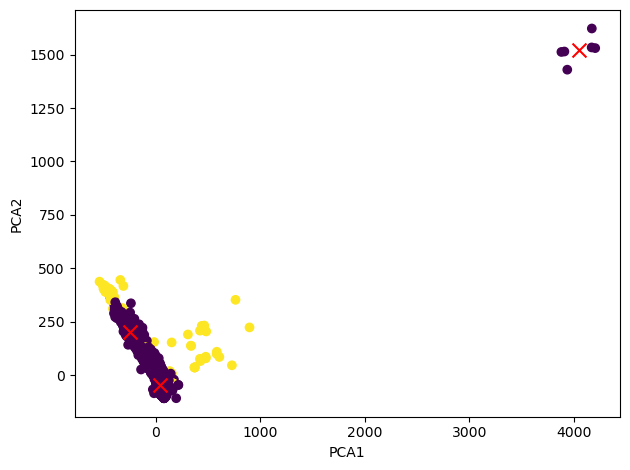

In [31]:
# Gráfico de datos y anomalías DATASET3
plt.scatter(results3['pca1'],results3['pca2'],c=data_scaled3['anomaly'])
plt.scatter(centers3[:,0],centers3[:,1],marker='x',s=100,c='red')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.tight_layout()

## Selección de características

### Estudio correlación

In [29]:
# Calculamos la correlación de los datos con la variable objetivo
correlation_matrix1 = data_scaled1.corr()
corr_vs_anomaly1 = correlation_matrix1['anomaly']

correlation_matrix2 = data_scaled2.corr()
corr_vs_anomaly2 = correlation_matrix2['anomaly']

correlation_matrix3 = data_scaled3.corr()
corr_vs_anomaly3 = correlation_matrix3['anomaly']

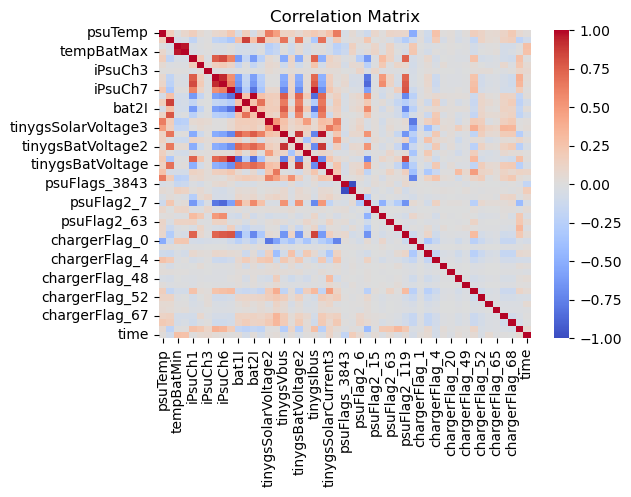

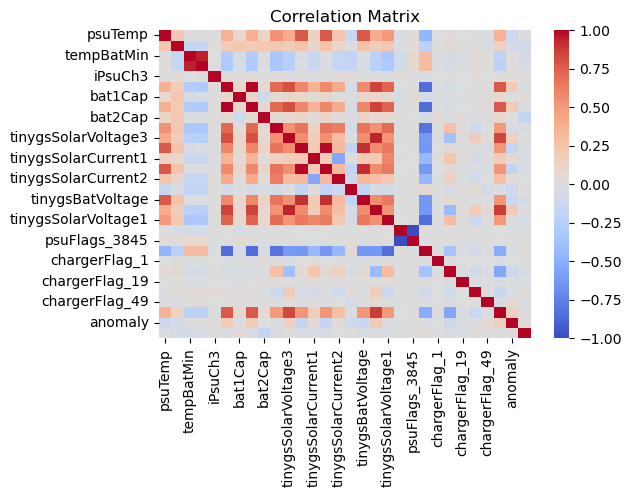

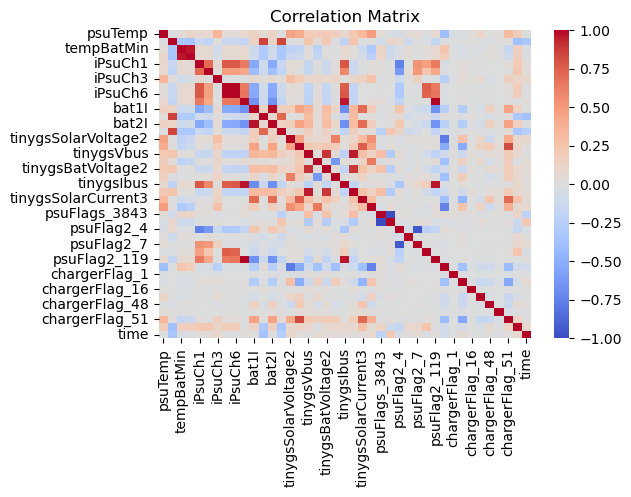

In [30]:
# Gráfico de correlaciones
plt.figure(figsize=(6, 4))  # Adjust the size to your needs
sns.heatmap(correlation_matrix1, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

plt.figure(figsize=(6, 4))  # Adjust the size to your needs
sns.heatmap(correlation_matrix2, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

plt.figure(figsize=(6, 4))  # Adjust the size to your needs
sns.heatmap(correlation_matrix3, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

In [31]:
# Observamos las correlaciones más significativas
print(corr_vs_anomaly1.sort_values(ascending=True))
print()
print(corr_vs_anomaly2.sort_values(ascending=True))
print()
print(corr_vs_anomaly3.sort_values(ascending=True))

psuFlag2_7            -0.418656
tinygsVbus            -0.263224
tinygsBatVoltage      -0.247254
tinygsBatVoltage2     -0.246082
bat1Cap               -0.211793
batCharge             -0.208824
bat2Cap               -0.196488
bat1I                 -0.173452
bat2I                 -0.168474
chargerFlag_4         -0.071684
chargerFlag_68        -0.060866
chargerFlag_52        -0.049133
chargerFlag_67        -0.042777
chargerFlag_0         -0.034209
chargerFlag_64        -0.023466
psuFlags_3843         -0.023214
chargerFlag_65        -0.016239
chargerFlag_1         -0.013501
chargerFlag_20        -0.011017
psuFlag2_15           -0.010055
psuFlag2_6            -0.008705
tempBatMin             0.004247
tinygsSolarVoltage2    0.005303
tempBatMax             0.010984
tinygsSolarVoltage3    0.011543
chargerFlag_49         0.012155
chargerFlag_48         0.022204
psuFlags_3846          0.023214
chargerFlag_19         0.033612
tinygsSolarCurrent2    0.037654
tinygsSolarVoltage1    0.040627
time    

### Estudio información mutua

In [32]:
# Separamos la variable objetivo
XF = data_scaledF.drop(columns=['anomaly'])
YF = data_scaledF['anomaly']

X1 = data_scaled1.drop(columns=['anomaly'])
Y1 = data_scaled1['anomaly']

X2 = data_scaled2.drop(columns=['anomaly'])
Y2 = data_scaled2['anomaly']

X3 = data_scaled3.drop(columns=['anomaly'])
Y3 = data_scaled3['anomaly']

In [33]:
# Calculamos la información mutua, y la agrupamos en un dataframe
mi_scoresF = mutual_info_classif(XF, YF)
mi_scores1 = mutual_info_classif(X1, Y1)
mi_scores2 = mutual_info_classif(X2, Y2)
mi_scores3 = mutual_info_classif(X3, Y3)

data_mi_F = {'info_score': mi_scoresF}
data_mi_1 = {'info_score': mi_scores1}
data_mi_2 = {'info_score': mi_scores2}
data_mi_3 = {'info_score': mi_scores3}

info_mutuaF = pd.DataFrame(data=data_mi_F, index=XF.columns)
info_mutua1 = pd.DataFrame(data=data_mi_1, index=X1.columns)
info_mutua2 = pd.DataFrame(data=data_mi_2, index=X2.columns)
info_mutua3 = pd.DataFrame(data=data_mi_3, index=X3.columns)

In [34]:
# Filtramos los campos con información inferior a 0.05
variables_irrelevantesF = list(info_mutuaF[info_mutuaF['info_score']<0.005].index)
variables_irrelevantes1 = list(info_mutua1[info_mutua1['info_score']<0.005].index)
variables_irrelevantes2 = list(info_mutua2[info_mutua2['info_score']<0.005].index)
variables_irrelevantes3 = list(info_mutua3[info_mutua3['info_score']<0.005].index)

In [35]:
# Se descartan las variables irrelevantes de cada dataset
data_selectedF = data_scaledF.drop(columns=variables_irrelevantesF)
data_selected1 = data_scaled1.drop(columns=variables_irrelevantes1)
data_selected2 = data_scaled2.drop(columns=variables_irrelevantes2)
data_selected3 = data_scaled3.drop(columns=variables_irrelevantes3)

In [36]:
print(data_selectedF.shape)
print(data_selected1.shape)
print(data_selected2.shape)
print(data_selected3.shape)

(8844, 33)
(2614, 29)
(3219, 20)
(3011, 27)


In [38]:
print(YF.value_counts())
print(Y1.value_counts())
print(Y2.value_counts())
print(Y3.value_counts())

anomaly
0    8401
1     443
Name: count, dtype: int64
anomaly
0    2483
1     131
Name: count, dtype: int64
anomaly
0    3058
1     161
Name: count, dtype: int64
anomaly
0    2860
1     151
Name: count, dtype: int64


### Export sin dividir

In [39]:
# Movemos el tiempo a la primera posición
datos_completosF = data_selectedF[['time']+[col for col in data_selectedF.columns if col != 'time']]
datos_completos1 = data_selected1[['time']+[col for col in data_selected1.columns if col != 'time']]
datos_completos2 = data_selected2[['time']+[col for col in data_selected2.columns if col != 'time']]
datos_completos3 = data_selected3[['time']+[col for col in data_selected3.columns if col != 'time']]

# Reordenamos los datos de forma temporal
datos_completosF = datos_completosF.sort_values(by='time')
datos_completos1 = datos_completos1.sort_values(by='time')
datos_completos2 = datos_completos2.sort_values(by='time')
datos_completos3 = datos_completos3.sort_values(by='time')

# Exportamos el dataset de entrenamiento
datos_completosF.to_excel("datos_completosF.xlsx")
datos_completos1.to_excel("datos_completos1.xlsx")
datos_completos2.to_excel("datos_completos2.xlsx")
datos_completos3.to_excel("datos_completos3.xlsx")

## División train-test (Random)

In [38]:
# Separamos la variable objetivo del dataset
X1 = data_selected1.drop('anomaly', axis=1)
y1 = data_selected1['anomaly']

X2 = data_selected2.drop('anomaly', axis=1)
y2 = data_selected2['anomaly']

X3 = data_selected3.drop('anomaly', axis=1)
y3 = data_selected3['anomaly']

In [156]:
# Dividimos los datos: 80% train, 20% test
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=33)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=34)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=35)

In [157]:
print(y1_test.value_counts())
print(y2_test.value_counts())
print(y3_test.value_counts())

anomaly
0    496
1     27
Name: count, dtype: int64
anomaly
0    609
1     35
Name: count, dtype: int64
anomaly
0    577
1     26
Name: count, dtype: int64


In [158]:
print(y1_train.value_counts())
print(y2_train.value_counts())
print(y3_train.value_counts())

anomaly
0    1987
1     104
Name: count, dtype: int64
anomaly
0    2449
1     126
Name: count, dtype: int64
anomaly
0    2283
1     125
Name: count, dtype: int64


In [159]:
# Concatenamos los datos
datos_validacion1 = X1_test
datos_validacion1['anomaly'] = y1_test

datos_validacion2 = X2_test
datos_validacion2['anomaly'] = y2_test

datos_validacion3 = X3_test
datos_validacion3['anomaly'] = y3_test

datos_entrenamiento1 = X1_train
datos_entrenamiento1['anomaly'] = y1_train

datos_entrenamiento2 = X2_train
datos_entrenamiento2['anomaly'] = y2_train

datos_entrenamiento3 = X3_train
datos_entrenamiento3['anomaly'] = y3_train

In [160]:
# Movemos el tiempo a la primera posición
datos_validacion1 = datos_validacion1[['time']+[col for col in datos_validacion1.columns if col != 'time']]
datos_validacion2 = datos_validacion2[['time']+[col for col in datos_validacion2.columns if col != 'time']]
datos_validacion3 = datos_validacion3[['time']+[col for col in datos_validacion3.columns if col != 'time']]

# Reordenamos los datos de forma temporal
datos_validacion1 = datos_validacion1.sort_values(by='time')
datos_validacion2 = datos_validacion2.sort_values(by='time')
datos_validacion3 = datos_validacion3.sort_values(by='time')

# Exportamos el dataset de validación
datos_validacion1.to_excel("datos_validacion_rand_sat1.xlsx")
datos_validacion2.to_excel("datos_validacion_rand_sat2.xlsx")
datos_validacion3.to_excel("datos_validacion_rand_sat3.xlsx")

# Exportamos el dataset de entrenamiento
datos_entrenamiento1.to_excel("datos_entrenamiento_rand_sat1.xlsx")
datos_entrenamiento2.to_excel("datos_entrenamiento_rand_sat2.xlsx")
datos_entrenamiento3.to_excel("datos_entrenamiento_rand_sat3.xlsx")

## División train-test (Serie)

In [203]:
# Separamos la variable objetivo del dataset
Xs1 = data_selected1
Xs2 = data_selected2
Xs3 = data_selected3

In [204]:
# Movemos el tiempo a la primera posición
Xs1 = Xs1[['time']+[col for col in Xs1.columns if col != 'time']]
Xs2 = Xs2[['time']+[col for col in Xs2.columns if col != 'time']]
Xs3 = Xs3[['time']+[col for col in Xs3.columns if col != 'time']]

# Reordenamos los datos de forma temporal
Xs1 = Xs1.sort_values(by='time')
Xs2 = Xs2.sort_values(by='time')
Xs3 = Xs3.sort_values(by='time')

In [205]:
Xs1_norm = Xs1[Xs1.anomaly == 0]
Xs1_anom = Xs1[Xs1.anomaly == 1]

Xs2_norm = Xs2[Xs2.anomaly == 0]
Xs2_anom = Xs2[Xs2.anomaly == 1]

Xs3_norm = Xs3[Xs3.anomaly == 0]
Xs3_anom = Xs3[Xs3.anomaly == 1]

In [206]:
Xs3_anom.shape

(151, 32)

In [207]:
train_size1 = int(2*len(Xs1)/3)
train_size2 = int(2*len(Xs2)/3)
train_size3 = int(2*len(Xs3)/3)

In [208]:
len(Xs1)

2614

In [250]:
# Split into training and test sets -> ajuste de indices para separar en 0.33 train/0.33 validacion/0.33 test
train_data_1 = Xs1_norm.iloc[:train_size1]
test_data_1 = Xs1_norm.iloc[train_size1+1:]
test_data_1 = pd.concat([test_data_1, Xs1_anom], axis=0)

train_data_2 = Xs2_norm.iloc[:train_size2]
test_data_2 = Xs2_norm.iloc[train_size2:]
test_data_2 = pd.concat([test_data_2, Xs2_anom], axis=0)

train_data_3 = Xs3_norm.iloc[:train_size3-1]
test_data_3 = Xs3_norm.iloc[train_size3+1:]
test_data_3 = pd.concat([test_data_3, Xs3_anom], axis=0)

In [251]:
# Reordenamos los datos de forma temporal
train_data_1 = train_data_1.sort_values(by='time')
train_data_2 = train_data_2.sort_values(by='time')
train_data_3 = train_data_3.sort_values(by='time')

test_data_1 = test_data_1.sort_values(by='time')
test_data_2 = test_data_2.sort_values(by='time')
test_data_3 = test_data_3.sort_values(by='time')

In [252]:
# Exportamos los datos de entrenamiento
train_data_1.to_excel("datos_entrenamiento_serie_sat1.xlsx")
train_data_2.to_excel("datos_entrenamiento_serie_sat2.xlsx")
train_data_3.to_excel("datos_entrenamiento_serie_sat3.xlsx")

# Exportamos el dataset de validación
test_data_1.to_excel("datos_validacion_serie_sat1.xlsx")
test_data_2.to_excel("datos_validacion_serie_sat2.xlsx")
test_data_3.to_excel("datos_validacion_serie_sat3.xlsx")

## Upsampling

In [107]:
# Analizamos el dataset para ver el equilibrio de variables
distribution1 = datos_entrenamiento1['anomaly'].value_counts()
print(distribution1)

distribution2 = datos_entrenamiento2['anomaly'].value_counts()
print(distribution2)

distribution3 = datos_entrenamiento3['anomaly'].value_counts()
print(distribution3)

anomaly
0    1987
1     104
Name: count, dtype: int64
anomaly
0    2448
1     127
Name: count, dtype: int64
anomaly
0    2283
1     125
Name: count, dtype: int64


In [108]:
# Dividimos el dataset en las 2 clases
df_majority1 = datos_entrenamiento1[datos_entrenamiento1['anomaly'] == 0]
df_minority1 = datos_entrenamiento1[datos_entrenamiento1['anomaly'] == 1]

df_majority2 = datos_entrenamiento2[datos_entrenamiento2['anomaly'] == 0]
df_minority2 = datos_entrenamiento2[datos_entrenamiento2['anomaly'] == 1]

df_majority3 = datos_entrenamiento3[datos_entrenamiento3['anomaly'] == 0]
df_minority3 = datos_entrenamiento3[datos_entrenamiento3['anomaly'] == 1]

In [109]:
# Realizamos el upsampling de la clase minoritaria
df_minority_upsampled1 = resample(df_minority1,
                                   replace=True,
                                   n_samples=len(df_majority1),
                                   random_state=33)

df_minority_upsampled2 = resample(df_minority2,
                                   replace=True,
                                   n_samples=len(df_majority2),
                                   random_state=34)

df_minority_upsampled3 = resample(df_minority3,
                                   replace=True,
                                   n_samples=len(df_majority3),
                                   random_state=35)

data_upsampled1 = pd.concat([df_minority_upsampled1, df_majority1])
data_upsampled2 = pd.concat([df_minority_upsampled2, df_majority2])
data_upsampled3 = pd.concat([df_minority_upsampled3, df_majority3])

In [110]:
print(data_upsampled1['anomaly'].value_counts())
print(data_upsampled2['anomaly'].value_counts())
print(data_upsampled3['anomaly'].value_counts())

anomaly
1    1987
0    1987
Name: count, dtype: int64
anomaly
1    2448
0    2448
Name: count, dtype: int64
anomaly
1    2283
0    2283
Name: count, dtype: int64


In [111]:
# Movemos el tiempo a la primera posición
data_upsampled1 = data_upsampled1[['time']+[col for col in data_upsampled1.columns if col != 'time']]
data_upsampled2 = data_upsampled2[['time']+[col for col in data_upsampled2.columns if col != 'time']]
data_upsampled3 = data_upsampled3[['time']+[col for col in data_upsampled3.columns if col != 'time']]

# Reordenamos los datos de forma temporal
data_upsampled1 = data_upsampled1.sort_values(by='time')
data_upsampled2 = data_upsampled2.sort_values(by='time')
data_upsampled3 = data_upsampled3.sort_values(by='time')

# Exportamos los datos de entrenamiento
data_upsampled1.to_excel("datos_entrenamiento_sat1.xlsx")
data_upsampled2.to_excel("datos_entrenamiento_sat2.xlsx")
data_upsampled3.to_excel("datos_entrenamiento_sat3.xlsx")